## 1. Setup & Data Loading

In [24]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
import io
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [16]:
#Load Data
splits = {
    'train': 'mnist/train-00000-of-00001.parquet',
    'test':  'mnist/test-00000-of-00001.parquet'
}
train = pd.read_parquet('hf://datasets/ylecun/mnist/' + splits['train'])
test  = pd.read_parquet('hf://datasets/ylecun/mnist/' + splits['test'])

def image_to_vector(image_dict):
    img = Image.open(io.BytesIO(image_dict['bytes']))
    return np.array(img).flatten()

for df in (train, test):
    df['image_vector'] = df['image'].apply(image_to_vector)
    df['normalized_image_vector'] = df['image_vector'].apply(lambda x: x / 255.0)

X_train = np.array(train['normalized_image_vector'].to_list())
y_train = train['label'].to_numpy()
X_test  = np.array(test['normalized_image_vector'].to_list())
y_test  = test['label'].to_numpy()

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

BATCH = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH, shuffle=False)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (60000, 784) | Test: (10000, 784)


## 2. Model Definitions

In [17]:
#MLP
class MLP(nn.Module):
    def __init__(self, hidden_size=128):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 10)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


#CNN
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc    = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        return self.fc(x.reshape(x.size(0), -1))


#Transformer
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_channels=1, embed_dim=64):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)


class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, embed_dim)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, embed_dim, 2).float()
                        * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class ImageTransformer(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_channels=1, num_classes=10,
                 embed_dim=64, num_heads=4, num_layers=2, hidden_dim_mlp=128):
        super().__init__()
        self.img_size = img_size
        self.patch_embedding    = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=hidden_dim_mlp, dropout=0.1, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = x.view(-1, 1, self.img_size, self.img_size)
        x = self.patch_embedding(x)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        return self.classifier(x.mean(dim=1))



## 3. Train Models

In [18]:
def train_model(model, loader, epochs=5, lr=1e-3, name='Model'):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            opt.zero_grad()
            loss_fn(model(X_b), y_b).backward()
            opt.step()
    return model


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        preds = model(X_b).argmax(1)
        correct += (preds == y_b).sum().item()
        total   += len(y_b)
    return correct / total


print('Training MLP')
mlp_model = train_model(MLP(), train_loader, name='MLP')
print(f'  MLP  clean accuracy: {evaluate(mlp_model, test_loader):.4f}')

print('Training CNN')
cnn_model = train_model(CNN(), train_loader, name='CNN')
print(f'  CNN  clean accuracy: {evaluate(cnn_model, test_loader):.4f}')

print('Training Transformer')
tfm_model = train_model(ImageTransformer(), train_loader, name='Transformer')
print(f'  Transformer clean accuracy: {evaluate(tfm_model, test_loader):.4f}')

Training MLP
  MLP  clean accuracy: 0.9738
Training CNN
  CNN  clean accuracy: 0.9849
Training Transformer
  Transformer clean accuracy: 0.9700


## 4. Adversarial Attack Implementations


In [19]:
#FGSM
def fgsm(model, x, y, eps):
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True).to(device)
    loss  = nn.CrossEntropyLoss()(model(x_adv), y.to(device))
    loss.backward()
    with torch.no_grad():
        x_adv = x_adv + eps * x_adv.grad.sign()
        x_adv = x_adv.clamp(0.0, 1.0)
    return x_adv.detach()


#I-FGSM / PGD
def ifgsm(model, x, y, eps, alpha=None, steps=40, random_start=True):
    if alpha is None:
        alpha = eps / 4
    model.eval()
    x,y = x.to(device),y.to(device)
    x_adv  = x.clone().detach()
    if random_start:
        x_adv = x_adv + torch.empty_like(x_adv).uniform_(-eps, eps)
        x_adv = x_adv.clamp(0.0, 1.0)

    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = nn.CrossEntropyLoss()(model(x_adv), y)
        loss.backward()
        with torch.no_grad():
            x_adv = x_adv + alpha * x_adv.grad.sign()
            delta = (x_adv - x).clamp(-eps, eps)
            x_adv = (x + delta).clamp(0.0, 1.0).detach()

    return x_adv


#Momentum I-FGSM
def mifgsm(model, x, y, eps, alpha=None, steps=40, mu=1.0):
    if alpha is None:
        alpha = eps / 4
    model.eval()
    x = x.to(device)
    y = y.to(device)
    x_adv = x.clone().detach()
    g = torch.zeros_like(x)  # momentum accumulator

    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = nn.CrossEntropyLoss()(model(x_adv), y)
        loss.backward()
        with torch.no_grad():
            grad = x_adv.grad.detach()
            # normalize by L1 norm then accumulate momentum
            grad_norm = grad / (grad.abs().mean(dim=list(range(1, grad.dim())),
                                               keepdim=True) + 1e-8)
            g = mu * g + grad_norm
            x_adv = x_adv + alpha * g.sign()
            delta = (x_adv - x).clamp(-eps, eps)
            x_adv = (x + delta).clamp(0.0, 1.0).detach()

    return x_adv



## 5. Evaluation Helpers

In [20]:
def compute_asr(model, loader, attack_fn, **attack_kwargs):
    model.eval()
    fooled, total_correct = 0, 0

    for X_pred, y_pred in loader:
        X_pred, y_pred = X_pred.to(device), y_pred.to(device)

        with torch.no_grad():
            clean_pred = model(X_pred).argmax(1)
        correct_mask = (clean_pred == y_pred)
        if correct_mask.sum() == 0:
            continue
        X_c = X_pred[correct_mask]
        y_c = y_pred[correct_mask]

        X_adv = attack_fn(model, X_c, y_c, **attack_kwargs)

        with torch.no_grad():
            adv_pred = model(X_adv).argmax(1)

        fooled += (adv_pred != y_c).sum().item()
        total_correct += correct_mask.sum().item()

    return fooled / total_correct if total_correct > 0 else 0.0



## 6. Adversarial Attacks

In [21]:
EPSILONS   = [0.05, 0.1, 0.2, 0.3]
MODELS     = {'MLP': mlp_model, 'CNN': cnn_model, 'Transformer': tfm_model}
ATTACKS    = {
    'FGSM':    lambda model, x, y, eps: fgsm(model, x, y, eps),
    'I-FGSM':  lambda model, x, y, eps: ifgsm(model, x, y, eps, steps=40, random_start=True),
    'MI-FGSM': lambda model, x, y, eps: mifgsm(model, x, y, eps, steps=40, mu=1.0),
}

# clean recognition rate
clean_rr = {name: evaluate(m, test_loader) for name, m in MODELS.items()}
print('Clean Recognition Rates:')
for name, rr in clean_rr.items():
    print(f'  {name:<14}: {rr*100:.2f}%')

results = []

for model_name, model in MODELS.items():
    for atk_name, atk_fn in ATTACKS.items():
        for eps in EPSILONS:
            print(f'{atk_name} for {model_name} with ε={eps:.2f}:', end=' ')
            asr = compute_asr(model, test_loader, atk_fn, eps=eps)
            print(f'ASR={asr*100:.1f}%')
            results.append({
                'Model':   model_name,
                'Attack':  atk_name,
                'Epsilon': eps,
                'Clean RR': clean_rr[model_name],
                'ASR':     asr
            })

import pandas as pd
df_results = pd.DataFrame(results)


Clean Recognition Rates:
  MLP           : 97.38%
  CNN           : 98.49%
  Transformer   : 97.00%
FGSM for MLP with ε=0.05: ASR=40.8%
FGSM for MLP with ε=0.10: ASR=88.2%
FGSM for MLP with ε=0.20: ASR=99.7%
FGSM for MLP with ε=0.30: ASR=100.0%
I-FGSM for MLP with ε=0.05: ASR=49.0%
I-FGSM for MLP with ε=0.10: ASR=94.5%
I-FGSM for MLP with ε=0.20: ASR=100.0%
I-FGSM for MLP with ε=0.30: ASR=100.0%
MI-FGSM for MLP with ε=0.05: ASR=47.9%
MI-FGSM for MLP with ε=0.10: ASR=94.2%
MI-FGSM for MLP with ε=0.20: ASR=100.0%
MI-FGSM for MLP with ε=0.30: ASR=100.0%
FGSM for CNN with ε=0.05: ASR=6.3%
FGSM for CNN with ε=0.10: ASR=27.6%
FGSM for CNN with ε=0.20: ASR=81.7%
FGSM for CNN with ε=0.30: ASR=94.3%
I-FGSM for CNN with ε=0.05: ASR=9.1%
I-FGSM for CNN with ε=0.10: ASR=53.2%
I-FGSM for CNN with ε=0.20: ASR=99.9%
I-FGSM for CNN with ε=0.30: ASR=100.0%
MI-FGSM for CNN with ε=0.05: ASR=9.2%
MI-FGSM for CNN with ε=0.10: ASR=53.5%
MI-FGSM for CNN with ε=0.20: ASR=100.0%
MI-FGSM for CNN with ε=0.30: AS

## 7. Results Table

In [22]:
pivot = df_results.pivot_table(
    index=['Model', 'Clean RR'],
    columns=['Attack', 'Epsilon'],
    values='ASR'
)
pivot.columns = [f'{atk} ε={eps}' for atk, eps in pivot.columns]
pivot.index   = [f'{m} (RR={rr*100:.1f}%)' for m, rr in pivot.index]

display(pivot.style
    .format('{:.2%}')
    .set_caption('Attack Success Rate (ASR) by Model × Attack × ε')
)

,FGSM ε=0.05,FGSM ε=0.1,FGSM ε=0.2,FGSM ε=0.3,I-FGSM ε=0.05,I-FGSM ε=0.1,I-FGSM ε=0.2,I-FGSM ε=0.3,MI-FGSM ε=0.05,MI-FGSM ε=0.1,MI-FGSM ε=0.2,MI-FGSM ε=0.3
CNN (RR=98.5%),6.32%,27.65%,81.73%,94.34%,9.15%,53.17%,99.95%,100.00%,9.21%,53.48%,99.98%,100.00%
MLP (RR=97.4%),40.79%,88.18%,99.70%,99.96%,49.04%,94.54%,99.99%,100.00%,47.86%,94.19%,99.99%,100.00%
Transformer (RR=97.0%),22.76%,65.56%,92.18%,97.08%,31.02%,89.03%,99.94%,100.00%,30.28%,86.71%,99.81%,100.00%


## 8. Visualizations

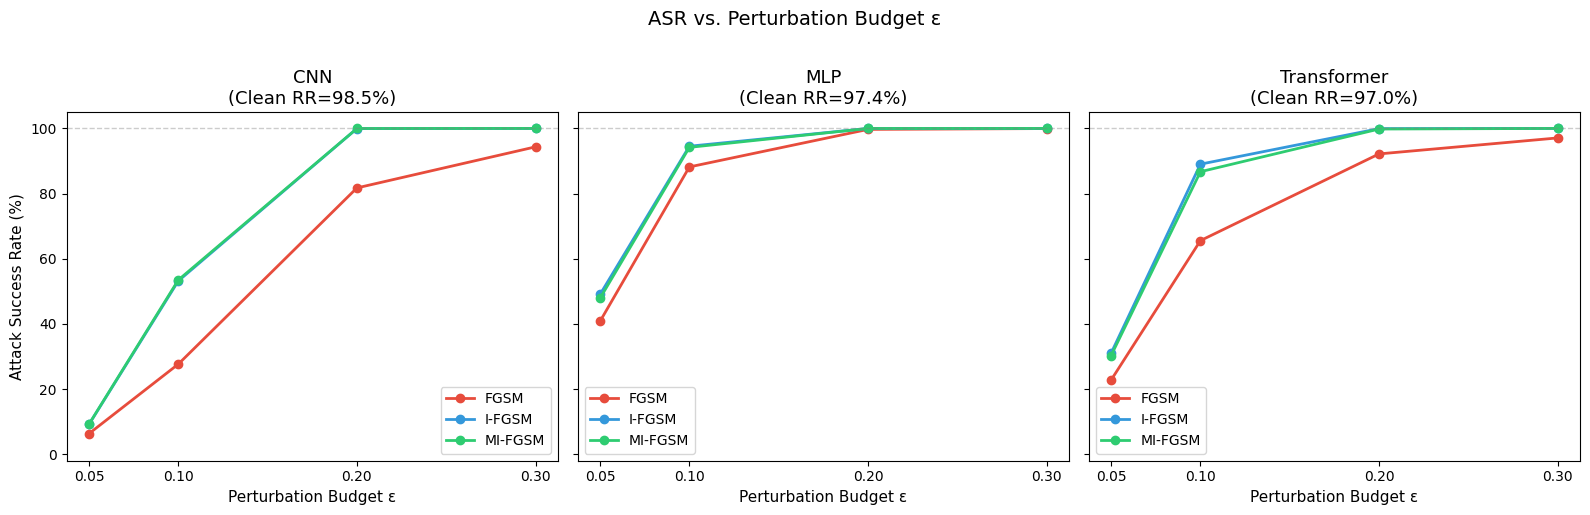

In [23]:
# ── 8a. ASR vs ε line plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
colors = {'FGSM': '#e74c3c', 'I-FGSM': '#3498db', 'MI-FGSM': '#2ecc71'}

for ax, (model_name, group) in zip(axes, df_results.groupby('Model')):
    for atk_name, sub in group.groupby('Attack'):
        sub = sub.sort_values('Epsilon')
        ax.plot(sub['Epsilon'], sub['ASR'] * 100,
                marker='o', label=atk_name, color=colors[atk_name], linewidth=2)
    ax.axhline(y=100, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.set_title(f'{model_name}\n(Clean RR={clean_rr[model_name]*100:.1f}%)', fontsize=13)
    ax.set_xlabel('Perturbation Budget ε', fontsize=11)
    ax.set_ylim(-2, 105)
    ax.set_xticks(EPSILONS)
    ax.legend()

axes[0].set_ylabel('Attack Success Rate (%)', fontsize=11)
plt.suptitle('ASR vs. Perturbation Budget ε', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()